In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [4]:
wine = load_wine()

X = wine.data
feature_names = wine.feature_names

df = pd.DataFrame(X, columns=feature_names)

print('Dataset Shape: ',df.shape)
print('\nFirst 5 rows: ')
print(df.head())

Dataset Shape:  (178, 13)

First 5 rows: 
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_di

In [5]:
# Scaling the features: alcohol & malic_acid

scaled = StandardScaler()
x_scaled = scaled.fit_transform(df[['alcohol', 'malic_acid']].values)

print('Feature Scaling Completed')

Feature Scaling Completed


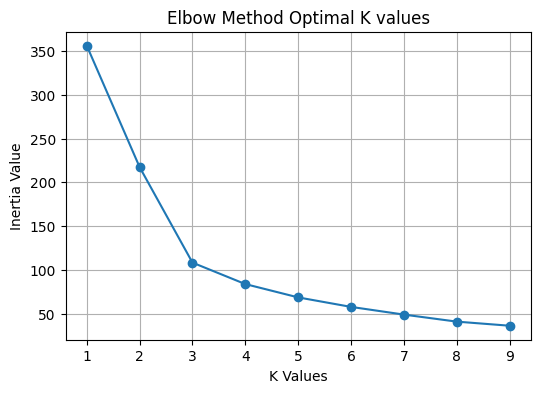

In [18]:
inertia_values = []
K_values = range(1, 10)

for k in K_values:
    kmeans = KMeans(n_clusters=k, n_init=100, random_state=42, init='k-means++')
    kmeans.fit(x_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_values, inertia_values, marker='o')
plt.title('Elbow Method Optimal K values')
plt.xlabel('K Values')
plt.ylabel('Inertia Value')
plt.grid(True)

In [25]:
kmeans = KMeans(n_clusters=3, n_init=100, random_state=42)
cluster = kmeans.fit_predict(x_scaled)

df['Cluster'] = cluster

print('\nCluster Centers (Scaled Value):')
print(kmeans.cluster_centers_)


Cluster Centers (Scaled Value):
[[-0.98858319 -0.5829103 ]
 [ 0.09906621  1.41480748]
 [ 0.87009843 -0.493973  ]]


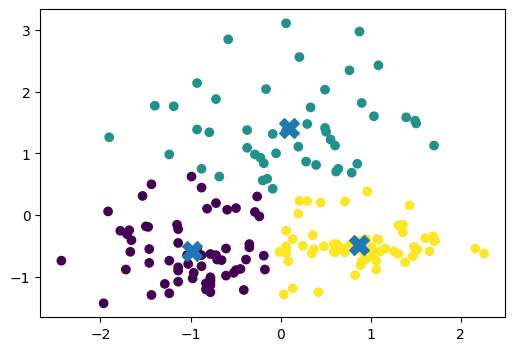

In [28]:
plt.figure(figsize=(6,4))

# Cluster Plotting
plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c=cluster
)

# Centroid Plotting
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X'
)

In [33]:
silh_score = silhouette_score(x_scaled, cluster)
print(f'Silhouette Score: {silh_score:.4f}')

Silhouette Score: 0.4841


In [36]:
# Cluster Distribution

print('Number of Sample in each Cluster: ')
print(df['Cluster'].value_counts())

Number of Sample in each Cluster: 
Cluster
2    66
0    63
1    49
Name: count, dtype: int64
